<a href="https://colab.research.google.com/github/nuctan/customer_analysis/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt


In [86]:
df = pd.read_csv("customer_segmentation_data.csv")
df.describe()
df_temp= df.copy()

In [87]:
df_temp.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3834 entries, 0 to 3833
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minutes_watched  3725 non-null   float64
 1   CLV              3834 non-null   float64
 2   region           3834 non-null   int64  
 3   channel          3834 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 119.9 KB


In [88]:
df_temp.isnull().sum()
df_temp= df_temp.fillna(0)
df_temp.isnull().sum()


,0
minutes_watched,0
CLV,0
region,0
channel,0


<Axes: >

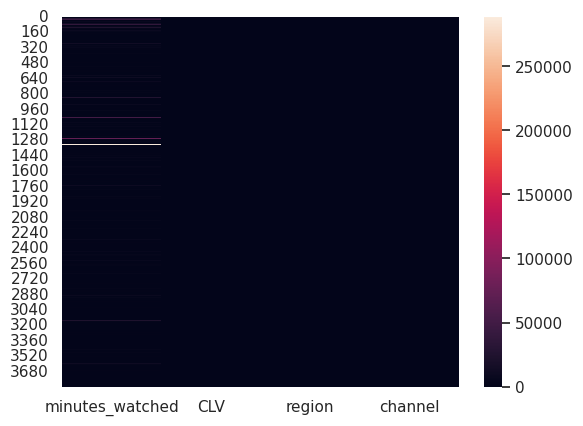

In [89]:
sns.heatmap(df_temp)

<Axes: >

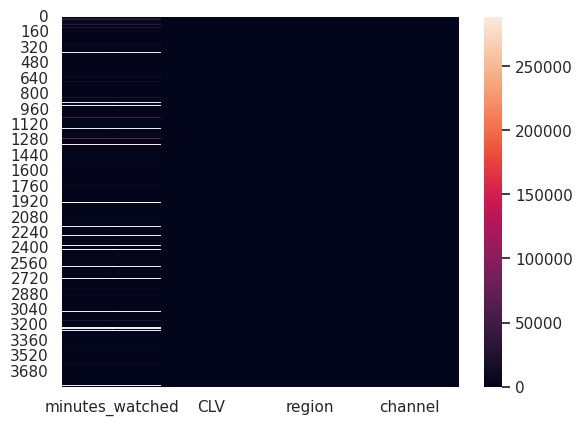

In [90]:
sns.heatmap(df)

In [91]:
display(df.corr())
display(df_temp.corr())

,minutes_watched,CLV,region,channel
minutes_watched,1.000000,0.117021,0.039048,-0.002699
CLV,0.117021,1.000000,-0.273312,-0.026359
region,0.039048,-0.273312,1.000000,0.015098
channel,-0.002699,-0.026359,0.015098,1.000000


,minutes_watched,CLV,region,channel
minutes_watched,1.000000,0.114153,0.040100,-0.003718
CLV,0.114153,1.000000,-0.273312,-0.026359
region,0.040100,-0.273312,1.000000,0.015098
channel,-0.003718,-0.026359,0.015098,1.000000


[Text(0.5, 0, 'minutes_watched'),
 Text(1.5, 0, 'CLV'),
 Text(2.5, 0, 'region'),
 Text(3.5, 0, 'channel')]

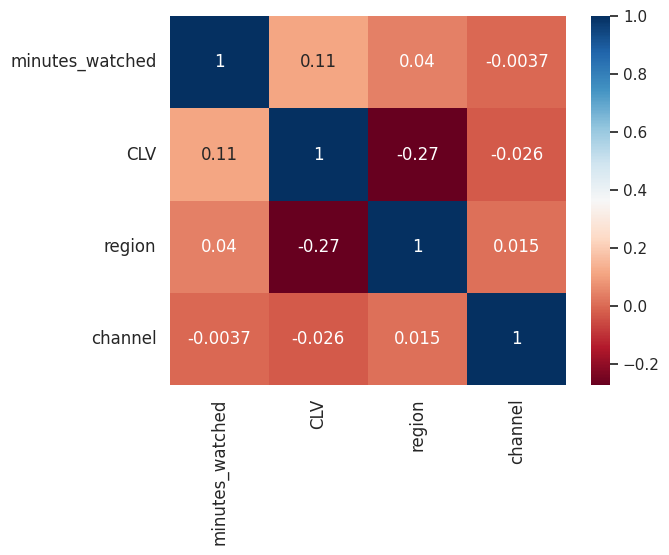

In [92]:
ax = sns.heatmap(df_temp.corr(), annot=True, cmap="RdBu")
ax.set_yticklabels(ax.get_yticklabels(), rotation = 0, fontsize = 12)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 12)

In [93]:
encoded_df = pd.get_dummies(
    df,
    columns=['region', 'channel'],
    drop_first=True
)
display(encoded_df)

,minutes_watched,CLV,region_1,region_2,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8
0,3197.0,205.42,False,True,False,False,True,False,False,False,False
1,63.0,149.99,False,False,False,False,False,False,False,False,False
2,605.0,119.00,False,True,True,False,False,False,False,False,False
3,20.0,240.00,False,True,False,False,True,False,False,False,False
4,245.0,184.36,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3829,11.0,79.00,False,False,False,True,False,False,False,False,False
3830,28.0,79.00,False,False,True,False,False,False,False,False,False
3831,57.0,36.00,False,True,True,False,False,False,False,False,False
3832,44.0,36.00,False,True,False,False,False,False,False,False,False


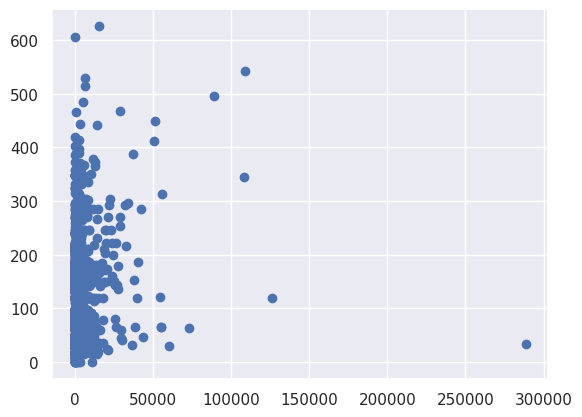

In [94]:
plt.scatter(df['minutes_watched'], df['CLV'])

In [95]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

segmentation_std = scaler.fit_transform(df_temp)

In [97]:
hier_clust = linkage(np.nan_to_num(segmentation_std), method = 'ward')

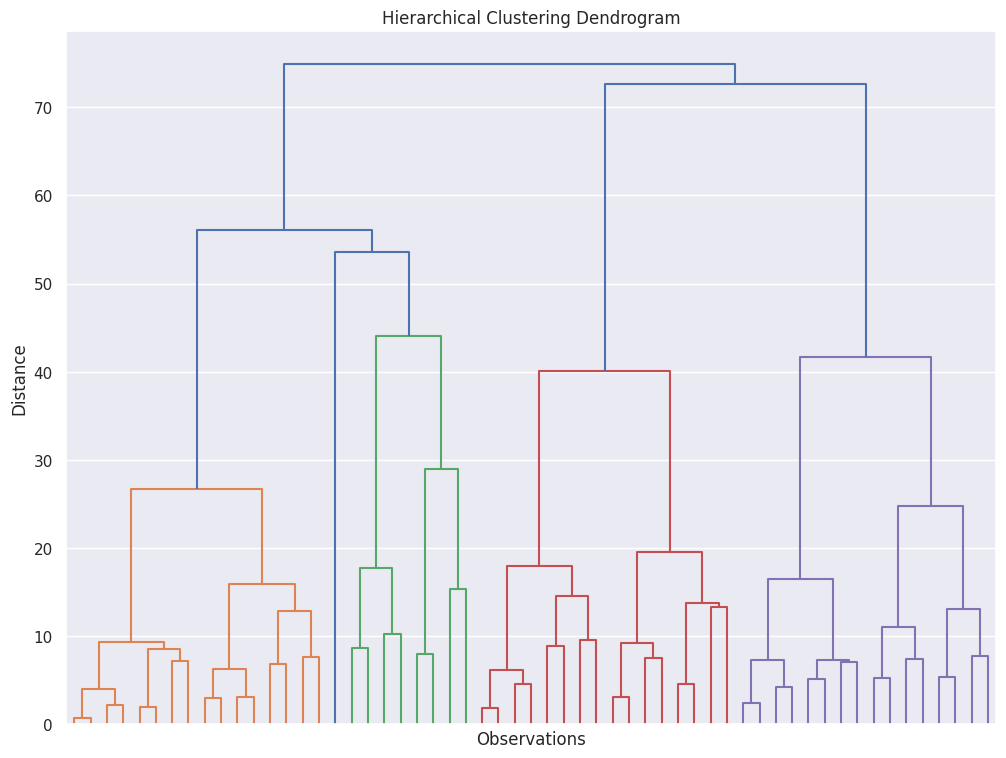

In [98]:
plt.figure(figsize = (12,9))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')
dendrogram(hier_clust,
           truncate_mode = 'level',
           p = 5,
           show_leaf_counts = False,
           no_labels = True)
plt.show()

In [99]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(segmentation_std)
    wcss.append(kmeans.inertia_)

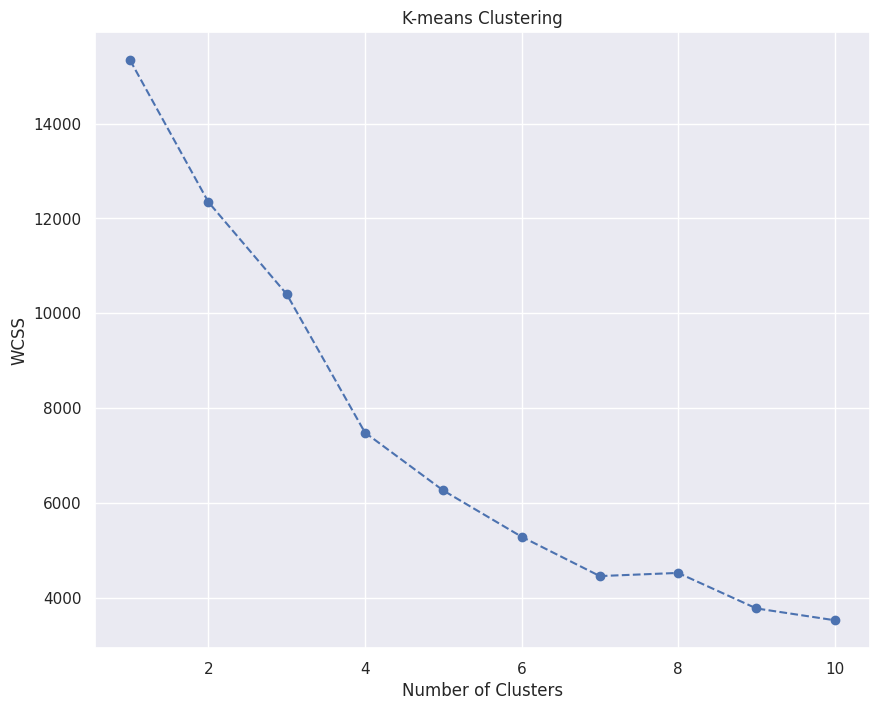

In [100]:
plt.figure(figsize = (10,8))
plt.plot(range(1, 11), wcss, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means Clustering')
plt.savefig('line_chart.png')
plt.show()

In [101]:
kmeans = KMeans(n_clusters = 8, init = 'k-means++', random_state = 42)

In [102]:
kmeans.fit(segmentation_std)

KMeans(random_state=42)

In [103]:
df_segm_kmeans = df_temp.copy()
df_segm_kmeans['Segment'] = kmeans.labels_

In [104]:
pd.set_option('display.max_columns', 500)

In [105]:
df_segm_analysis = df_segm_kmeans.groupby(['Segment']).mean()
df_segm_analysis

df_segm_analysis = df_segm_kmeans.groupby(['Segment']).mean()
df_segm_analysis

,minutes_watched,CLV,region,channel
Segment,,,,
0,1607.693095,169.930652,1.670077,2.680307
1,1041.986721,134.618631,0.000000,2.582227
2,1454.204489,56.942843,1.920200,6.723192
3,982.024725,133.071868,0.000000,7.096154
4,144241.800000,307.340000,1.200000,4.600000
5,1415.917683,159.922287,1.646341,6.875000
6,31698.346154,203.395385,1.192308,3.961538
7,1402.160347,57.818559,1.940412,2.656555


In [107]:
df_segm_analysis['N Obs'] = df_segm_kmeans.groupby('Segment').size()
df_segm_analysis['Prop Obs'] = df_segm_analysis['N Obs'] / df_segm_analysis['N Obs'].sum()


# Counting the number of observations in each segment.
# This is done by grouping by 'Segment' and counting the occurrences.
# 'Region_0' is used arbitrarily to count, as it exists in each segment.
df_segm_analysis['N Obs'] = df_segm_kmeans.groupby('Segment').size()

# Calculating the proportion of observations in each segment.
# This is done by dividing the number of observations in a segment by the total number of observations.
df_segm_analysis['Prop Obs'] = df_segm_analysis['N Obs'] / df_segm_analysis['N Obs'].sum()

In [108]:
df_segm_analysis.round(2)

,minutes_watched,CLV,region,channel,N Obs,Prop Obs
Segment,,,,,,
0,1607.69,169.93,1.67,2.68,782,0.20
1,1041.99,134.62,0.00,2.58,979,0.26
2,1454.20,56.94,1.92,6.72,401,0.10
3,982.02,133.07,0.00,7.10,364,0.09
4,144241.80,307.34,1.20,4.60,5,0.00
5,1415.92,159.92,1.65,6.88,328,0.09
6,31698.35,203.40,1.19,3.96,52,0.01
7,1402.16,57.82,1.94,2.66,923,0.24


In [109]:
df_segm_analysis.rename({0:'Instagram Explorers',
                         1:'LinkedIn Networkers',
                         2:'Friends\' Influence',
                         3:'Google-YouTube Mix',
                         4:'Anglo-Saxon Multi-Channel',
                         5:'European Multi-Channel',
                         6:'Twitter Devotees',
                         7:'Facebook Followers',
                        })


,minutes_watched,CLV,region,channel,N Obs,Prop Obs
Segment,,,,,,
Instagram Explorers,1607.693095,169.930652,1.670077,2.680307,782,0.203965
LinkedIn Networkers,1041.986721,134.618631,0.000000,2.582227,979,0.255347
Friends' Influence,1454.204489,56.942843,1.920200,6.723192,401,0.104591
Google-YouTube Mix,982.024725,133.071868,0.000000,7.096154,364,0.094940
Anglo-Saxon Multi-Channel,144241.800000,307.340000,1.200000,4.600000,5,0.001304
European Multi-Channel,1415.917683,159.922287,1.646341,6.875000,328,0.085550
Twitter Devotees,31698.346154,203.395385,1.192308,3.961538,52,0.013563
Facebook Followers,1402.160347,57.818559,1.940412,2.656555,923,0.240741


In [110]:
df_segm_kmeans['Labels'] = df_segm_kmeans['Segment'].map({0:'Instagram Explorers',
                         1:'LinkedIn Networkers',
                         2:'Friends\' Influence',
                         3:'Google-YouTube Mix',
                         4:'Anglo-Saxon Multi-Channel',
                         5:'European Multi-Channel',
                         6:'Twitter Devotees',
                         7:'Facebook Followers',
                        })

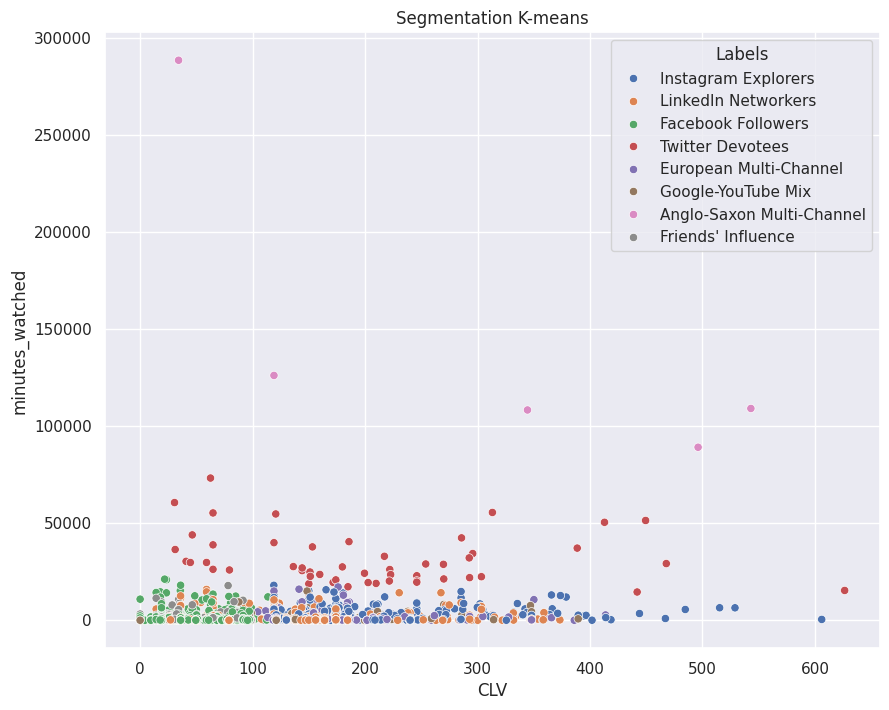

In [111]:
# Defining the x-axis data as 'total_payments' from the dataframe.
x_axis = df_segm_kmeans['CLV']

# Defining the y-axis data as 'minutes_watched' from the dataframe
y_axis = df_segm_kmeans['minutes_watched']

# Setting the figure size for the scatter plot.
plt.figure(figsize = (10, 8))

# Creating a scatter plot using seaborn.
# The 'hue' parameter colors the points based on the 'Labels' column, allowing for distinction between clusters.
sns.scatterplot(x = x_axis, y = y_axis, hue = df_segm_kmeans['Labels'])

# Setting the title of the scatter plot.
plt.title('Segmentation K-means')

# Displaying the scatter plot.
plt.show()